In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("titanic.csv")


In [83]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [84]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [85]:
df.drop(columns=["Cabin"], inplace=True)

In [86]:
df["Age"].fillna(df["Age"].median(), inplace=True)
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode(),inplace=True)

/tmp/ipykernel_1651/634127914.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipykernel_1651/634127914.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [87]:
df.drop_duplicates(inplace=True)

In [88]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

In [89]:
#df['Sex']=df['Sex'].str.capitalize()

In [90]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [91]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.')
df['FirstName'] = df['Name'].str.split('.').str[1].str.strip()
df['Name'] = df['Title'] + " " + df['FirstName']
df.drop(columns=['Title', 'FirstName'], inplace=True)

In [94]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [95]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,Mr Owen Harris,0,22.0,1,0,A/5 21171,7.2500,None,2
1,2,1,1,Mrs John Bradley (Florence Briggs Thayer),1,38.0,1,0,PC 17599,71.2833,None,2
2,3,1,3,Miss Laina,1,26.0,0,0,STON/O2. 3101282,7.9250,None,1
3,4,1,1,Mrs Jacques Heath (Lily May Peel),1,35.0,1,0,113803,53.1000,None,2
4,5,0,3,Mr William Henry,0,35.0,0,0,373450,8.0500,None,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,Rev Juozas,0,27.0,0,0,211536,13.0000,None,1
887,888,1,1,Miss Margaret Edith,1,19.0,0,0,112053,30.0000,None,1
888,889,0,3,"Miss Catherine Helen ""Carrie""",1,28.0,1,2,W./C. 6607,23.4500,None,4
889,890,1,1,Mr Karl Howell,0,26.0,0,0,111369,30.0000,None,1


##Data Cleaning

1.Age has missing values → filled with median (avoids outlier bias)
2.Name column contains full names with titles → cleaned by extracting title and first name
3.Cabin has too many missing values → dropped

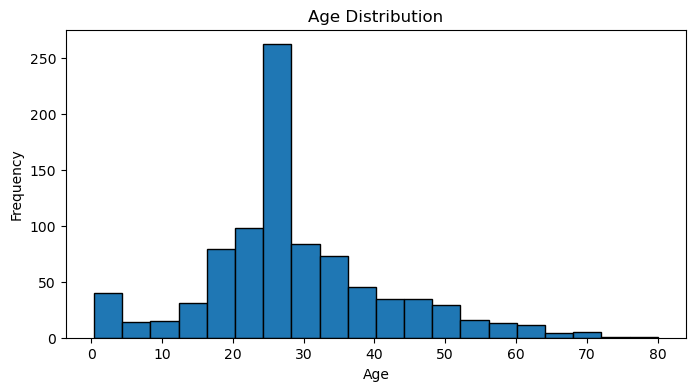

In [66]:
plt.figure(figsize=(8,4))
plt.hist(df['Age'], bins=20, edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

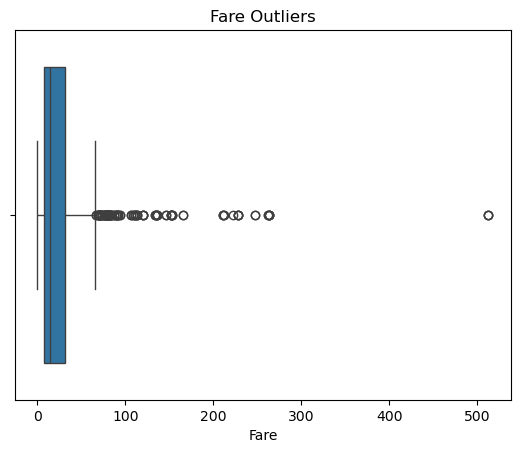

In [67]:
sns.boxplot(x=df['Fare'])
plt.title("Fare Outliers")
plt.show()

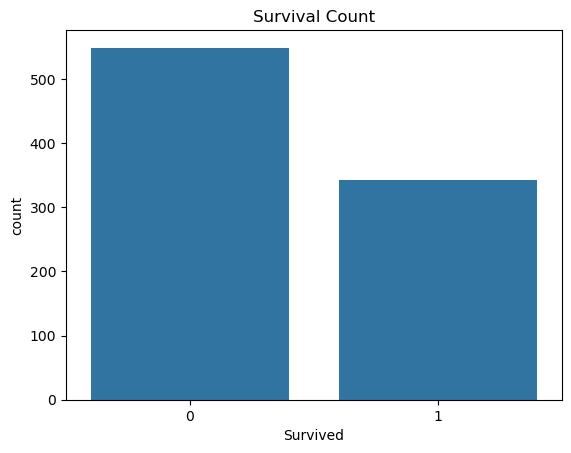

In [68]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

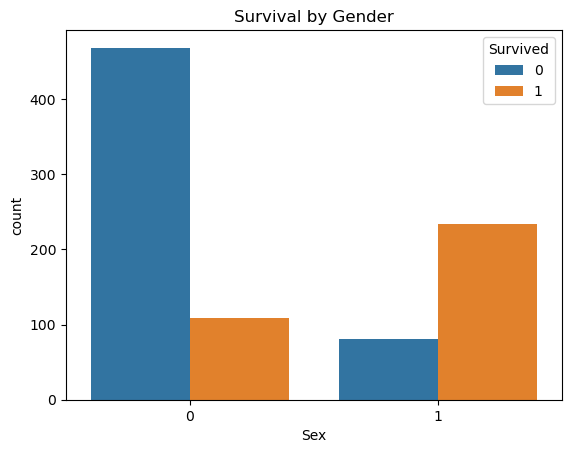

In [69]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

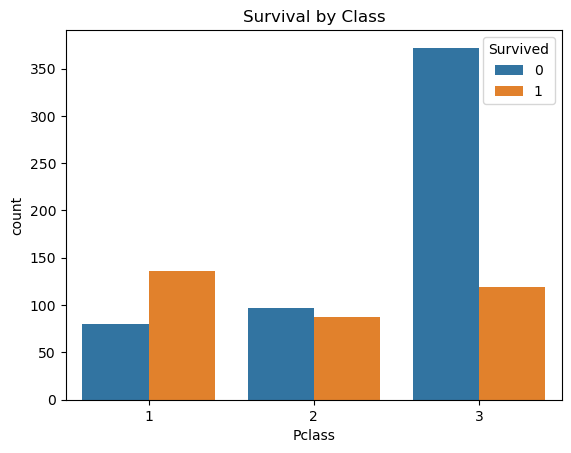

In [70]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Class")
plt.show()

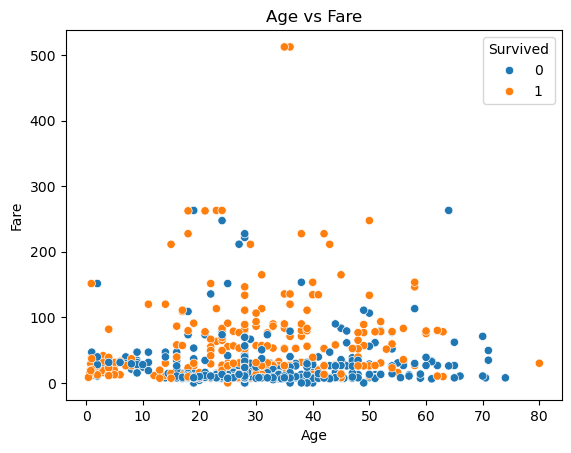

In [71]:
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title("Age vs Fare")
plt.show()

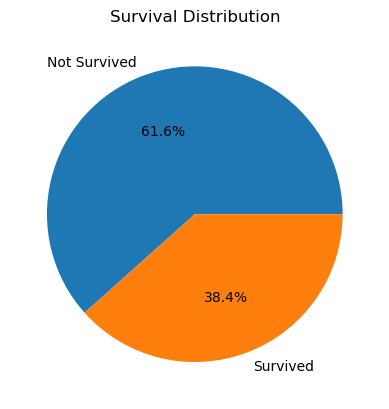

In [72]:
survival_counts = df['Survived'].value_counts()

plt.figure()
plt.pie(survival_counts, labels=['Not Survived', 'Survived'], autopct='%1.1f%%')
plt.title("Survival Distribution")
plt.show()

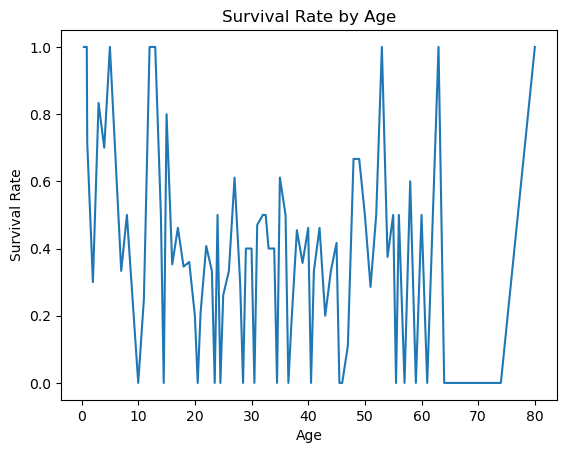

In [73]:
age_survival = df.groupby('Age')['Survived'].mean()


plt.plot(age_survival)
plt.title("Survival Rate by Age")
plt.xlabel("Age")
plt.ylabel("Survival Rate")
plt.show()

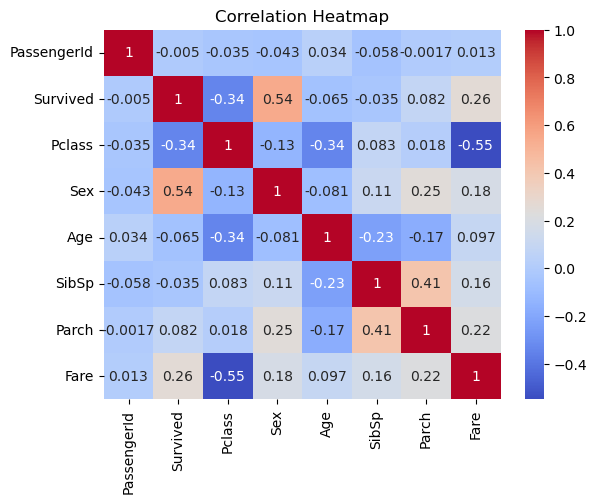

In [74]:
corr = df.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Observations

1. Most passengers were between 20–40 years old.
2. Females had a much higher survival rate than males.
3. First-class passengers had better survival chances.
4. Fare has outliers, showing very rich passengers existed.
5. Age alone does not strongly determine survival.

## What I would explore next

1. Whether adding new features like family size and title improves survival analysis.
2. How ticket fare combined with class affects survival patterns.
3. Identifying hidden patterns between age groups and passenger class.

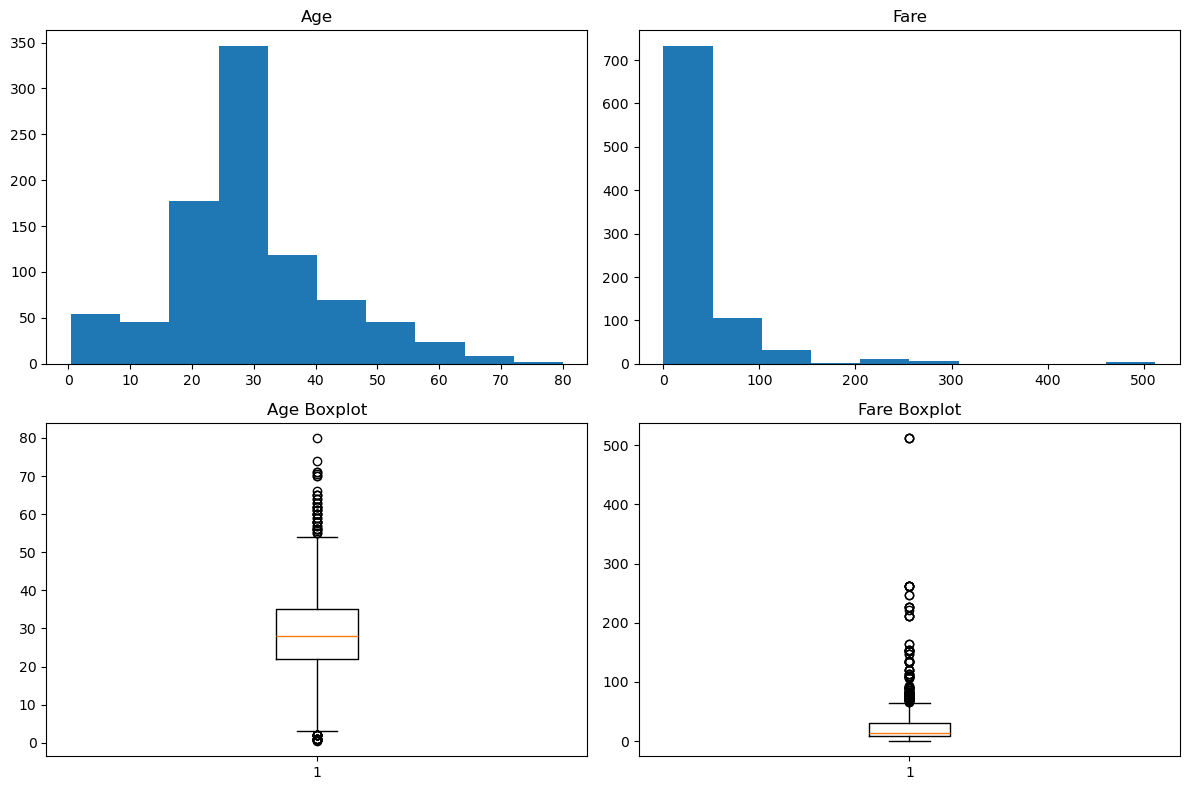

In [102]:
fig, ax = plt.subplots(2, 2, figsize=(12,8))

ax[0,0].hist(df['Age'])
ax[0,0].set_title("Age")

ax[0,1].hist(df['Fare'])
ax[0,1].set_title("Fare")

ax[1,0].boxplot(df['Age'].dropna())
ax[1,0].set_title("Age Boxplot")

ax[1,1].boxplot(df['Fare'].dropna())
ax[1,1].set_title("Fare Boxplot")

plt.tight_layout()
plt.show()

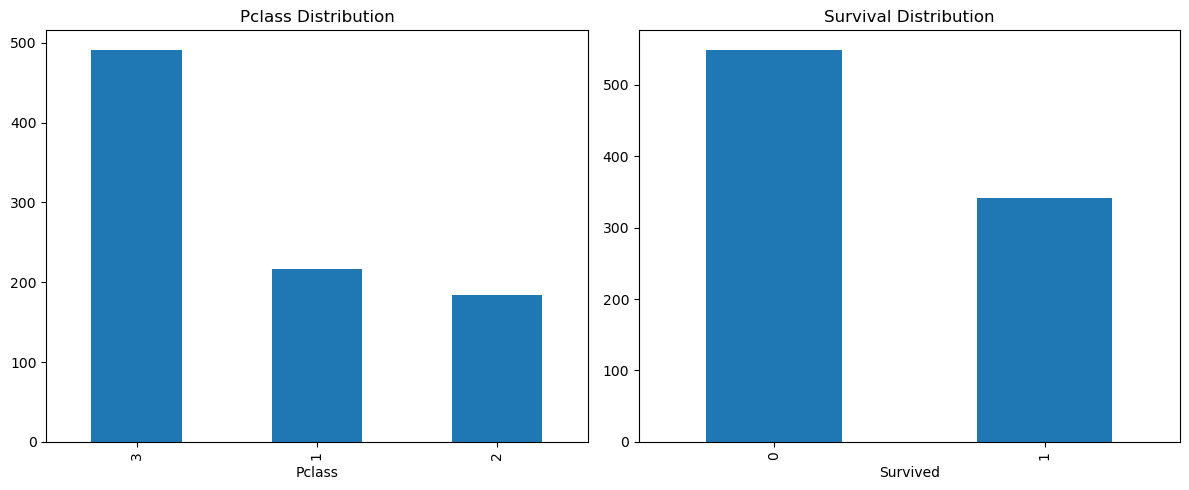

In [97]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

df['Pclass'].value_counts().plot(kind='bar', ax=ax[0])
ax[0].set_title("Pclass Distribution")

df['Survived'].value_counts().plot(kind='bar', ax=ax[1])
ax[1].set_title("Survival Distribution")

plt.tight_layout()
plt.show()

In [98]:
import streamlit as st

In [99]:
st.set_page_config(layout="wide")
st.title("Titanic Survival Dashboard 🚢")


2026-05-02 09:35:55.706 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
